## Modeling for predicting hospitalization at ED disposition

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve, get_lstm_data_gen
from dataset_path import output_path

df_train = pd.read_csv('mv_train_DISPOSITION.csv')
df_test = pd.read_csv('mv_test_DISPOSITION.csv')
df_val = pd.read_csv("mv_val_DISPOSITION.csv")
confidence_interval = 95
random_seed=0

2026-03-15 22:57:10.300801: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:57:10.333194: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 22:57:10.333233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 22:57:10.334404: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 22:57:10.340280: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 22:57:10.341261: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 

df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,228428,10870475,24160860.0,32267643,2118-02-13 23:54:00,2118-02-14 15:44:00,47,F,2118,NaN,2118-02-14 04:18:00,2118-02-14 15:44:00,NaN,WHITE,2118-02-13 23:54:00,2118-02-14 15:44:00,Other,2118,47,False,False,False,0 days 15:50:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,15.83,NaN,NaN,36.712811,85.085489,17.554838,98.374259,134.906695,77.480026,4.167576,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37.555556,84.0,18.0,97.0,114.0,74.0,5.0,8.0,0.0,96.622249,0,0,2,0,0,1,train,examination hand pa lat and oblique left indic...,['files/p1087/p10870475/s46566754/46566754']
1,7166,11258835,NaN,31208360,2175-04-18 13:54:00,2175-04-18 13:55:00,77,F,2175,NaN,NaN,NaN,NaN,WHITE,NaN,NaN,NaN,2175,77,False,False,False,0 days 00:01:00,NaN,NaN,False,False,False,0,0,0,2176-04-08 17:38:00,356 days 03:43:00,False,0,0,0,0,0,0,0.02,NaN,356.15,36.444444,73.000000,18.000000,96.000000,187.000000,97.000000,5.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.333333,73.0,18.0,97.0,145.0,93.0,0.0,5.0,12.0,127.000000,3,9,8,0,0,1,train,history screening comparison hologic digital s...,['files/p1125/p11258835/s41234765/41234765']
2,163449,19301404,NaN,37156637,2123-06-05 16:49:00,2123-06-05 17:20:00,20,F,2123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2123,20,False,False,False,0 days 00:31:00,NaN,NaN,False,False,False,1,1,1,2123-09-01 17:19:00,87 days 23:59:00,False,0,0,0,0,0,0,0.52,NaN,88.00,35.944444,89.000000,18.000000,100.000000,144.000000,87.000000,8.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.888889,80.0,18.0,100.0,111.0,71.0,2.0,1.0,1.0,106.000000,0,0,0,1,1,1,train,examination chest frontal and lateral views in...,['files/p1930/p19301404/s43791199/43791199']
3,40385,17101381,25853393.0,37075184,2130-05-06 16:51:00,2130-05-07 00:48:00,43,F,2125,NaN,2130-05-06 22:02:00,2130-05-08 14:45:00,NaN,WHITE,2130-05-06 16:51:00,2130-05-07 00:48:00,Other,2130,48,False,False,False,0 days 07:57:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,7.95,NaN,NaN,37.055556,71.000000,16.000000,100.000000,114.000000,77.000000,4.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.833333,81.0,18.0,98.0,108.0,67.0,4.0,0.0,10.0,89.333333,0,0,2,0,0,1,train,examination bilateral digital diagnostic mammo...,['files/p1710/p17101381/s43685824/43685824']
4,417338,14508231,29776374.0,32168097,2142-10-14 21:25:00,2142-10-15 04:11:16,49,F,2135,NaN,2142-10-15 04:10:00,2142-10-16 18:10:00,NaN,BLACK/AFRICAN AMERICAN,2142-10-14 21:25:00,2142-10-15 21:02:00,Other,2142,56,False,False,False,0 days 06:46:16,NaN,NaN,False,True,False,4,10,30,2142-10-28 18:18:00,13 days 14:06:44,False,0,2,6,0,0,0,6.77,NaN,13.59,36.888889,105.000000,16.000000,99.000000,190.000000,

### 1. task-specific filter: No specific filtering needed

In [4]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 151891 , testing size = 18987


### 2. Variable Selection

In [5]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache", 
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", "cci_Pulmonary", 
            "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", "cci_DM2", 
            "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", "cci_Cancer2", 
            "cci_HIV",
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",  
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss", 
            "eci_Anemia", "eci_Alcohol", "eci_Drugs", "eci_Psychoses", "eci_Depression",
            
            "ed_temperature_last", "ed_heartrate_last", "ed_resprate_last", 
            "ed_o2sat_last", "ed_sbp_last", "ed_dbp_last", "ed_los", "n_med", "n_medrecon"]

outcome = "outcome_hospitalization"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [7]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_los,n_med,n_medrecon
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,object,float64,float64


In [8]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [9]:
X_train['ed_los'] = pd.to_timedelta(X_train['ed_los']).dt.seconds / 60
X_test['ed_los'] = pd.to_timedelta(X_test['ed_los']).dt.seconds / 60
X_val['ed_los'] = pd.to_timedelta(X_val['ed_los']).dt.seconds / 60

In [10]:
print('class ratio')
print('positiave : negative =', y_train.sum()/(~y_train).sum(), ': 1')

class ratio
positiave : negative = 2.0879058326048505 : 1


### 3.  Modeling script

In [11]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 4.545895576477051 seconds
AUC: 0.9980534493963306
AUPRC: 0.9991046708995527
Sensitivity: 0.982870551427454
Specificity: 0.981941309255079
Score thresold: 0.5129966182708087
2.5 97.5


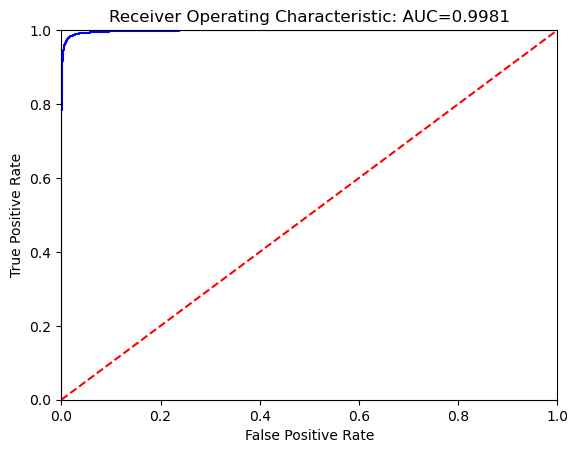

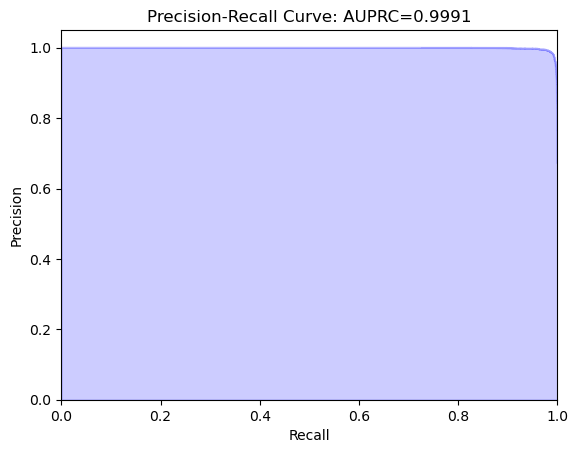

In [12]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task4_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 18.208696603775024 seconds
AUC: 0.997620905716639
AUPRC: 0.9986812666701634
Sensitivity: 0.9817755181853735
Specificity: 0.9843598839084167
Score thresold: 0.62
2.5 97.5


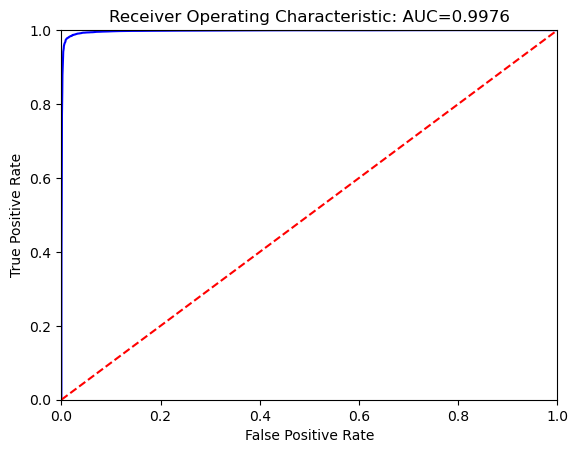

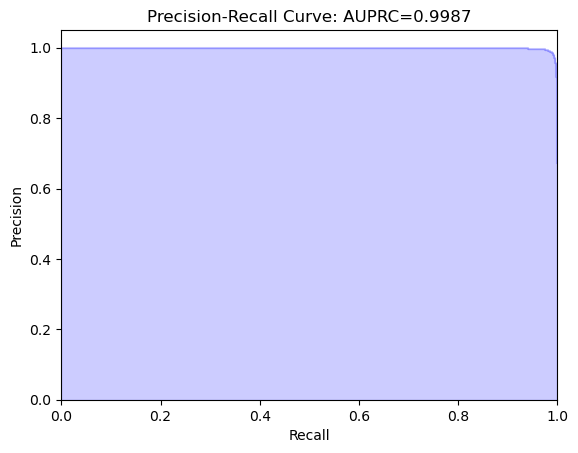

[1.80907402e-02 3.41481792e-03 1.42717039e-03 2.37408924e-03
 4.53978272e-03 2.51867737e-03 4.95948327e-03 5.51357898e-03
 3.42779724e-04 5.80021401e-04 1.86404867e-03 1.39866914e-02
 4.80523109e-02 1.66078446e-03 1.30437534e-03 1.70337580e-03
 1.46260657e-04 9.71161518e-04 7.23398493e-04 5.53804373e-04
 7.94556159e-04 5.30929433e-04 8.12237676e-04 8.62688148e-04
 1.50311836e-03 8.40713209e-04 7.95941719e-04 4.38113438e-04
 1.28274066e-03 5.63560185e-04 3.86866773e-04 9.32094054e-04
 1.27154666e-03 8.97286266e-04 3.45719224e-04 1.47246319e-03
 9.48261194e-04 5.35196377e-04 5.50028029e-04 2.51703719e-04
 1.37376258e-03 8.14739606e-04 7.40162954e-04 1.62646518e-03
 1.60449220e-03 9.38514633e-04 9.55125056e-04 3.35551332e-04
 1.28607437e-03 1.10484866e-03 7.89764431e-04 2.76599556e-03
 3.53837191e-04 8.10361060e-04 9.87984920e-04 8.19822820e-04
 5.84975233e-04 1.31017574e-03 9.96890712e-03 1.38580374e-02
 1.50130479e-02 8.72980744e-03 1.14883562e-02 1.67397139e-02
 7.08086670e-01 5.768026

In [13]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 33.460127115249634 seconds
AUC: 0.9981660072311946
AUPRC: 0.9991446407110883
Sensitivity: 0.9852170512319124
Specificity: 0.980651402773299
Score thresold: 0.5580084563634338
2.5 97.5


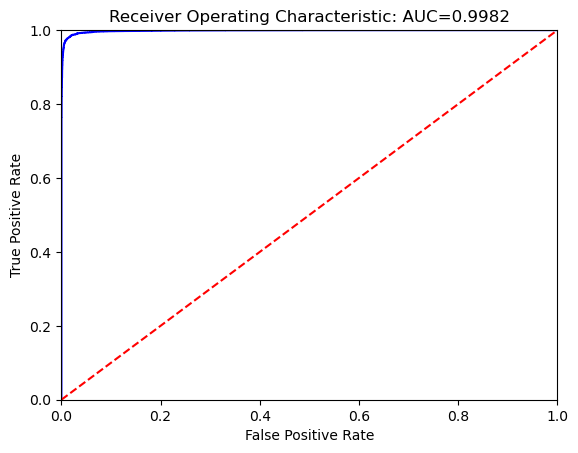

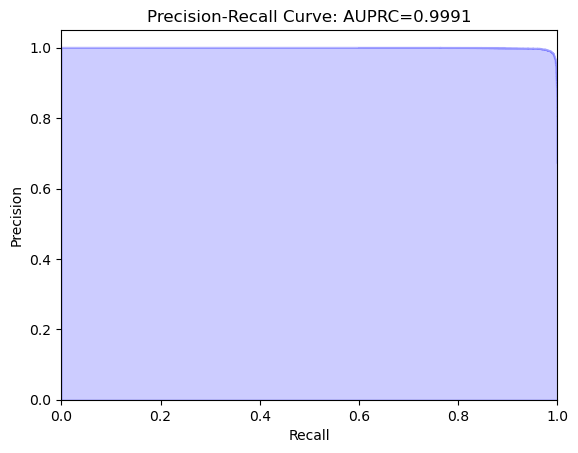

In [14]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [15]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task5.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.987616
1,1,0,0.011343
2,2,0,0.012877
3,3,0,0.004147
4,4,0,0.003101


GradientBoosting:
Training time: 33.11838388442993 seconds
AUC: 0.9981883680182939
AUPRC: 0.9991770977151698
Sensitivity: 0.9822595704948646
Specificity: 0.986957939354418
Score thresold: 0.7095020382109611
2.5 97.5


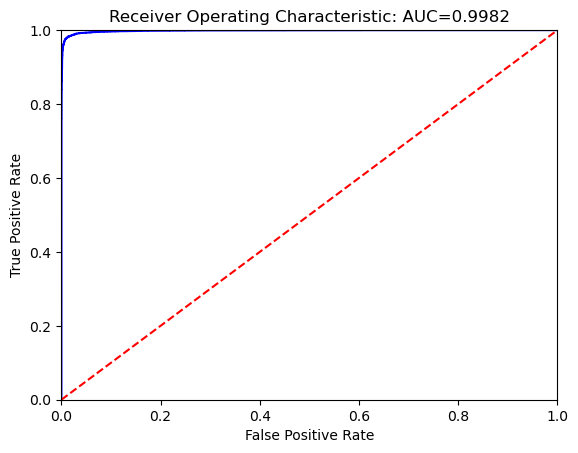

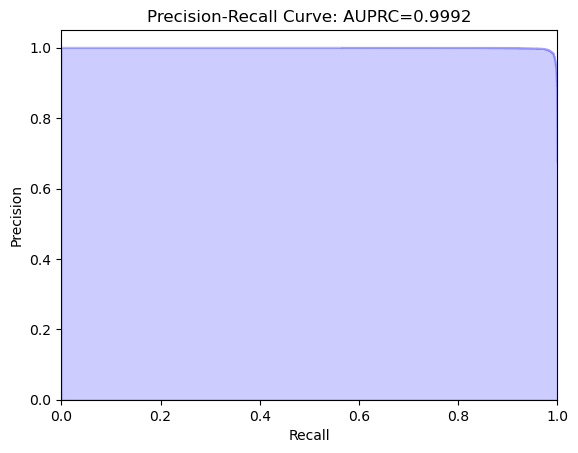

In [16]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [17]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task5.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.997023
1,1,1,0.998733
2,2,1,0.999352
3,3,1,0.996012
4,4,1,0.998882


In [18]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

Epoch 1/20


2026-03-15 22:58:50.059821: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agc04
2026-03-15 22:58:50.059847: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agc04
2026-03-15 22:58:50.059980: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-03-15 22:58:50.060012: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


760/760 [==============================] - 2s 1ms/step - loss: 0.0839 - accuracy: 0.9790 - auc: 0.9937 - auprc: 0.9958 - tp: 100996.0000 - tn: 47703.0000 - precision: 0.9855 - recall: 0.9834
Epoch 2/20
760/760 [==============================] - 1s 1ms/step - loss: 0.0568 - accuracy: 0.9812 - auc: 0.9966 - auprc: 0.9981 - tp: 101160.0000 - tn: 47883.0000 - precision: 0.9873 - recall: 0.9850
Epoch 3/20
760/760 [==============================] - 1s 1ms/step - loss: 0.0539 - accuracy: 0.9823 - auc: 0.9968 - auprc: 0.9981 - tp: 101180.0000 - tn: 48021.0000 - precision: 0.9886 - recall: 0.9852
Epoch 4/20
760/760 [==============================] - 1s 1ms/step - loss: 0.0521 - accuracy: 0.9825 - auc: 0.9971 - auprc: 0.9983 - tp: 101204.0000 - tn: 48031.0000 - precision: 0.9887 - recall: 0.9854
Epoch 5/20
760/760 [==============================] - 1s 1ms/step - loss: 0.0507 - accuracy: 0.9831 - auc: 0.9973 - auprc: 0.9985 - tp: 101260.0000 - tn: 48071.0000 - precision: 0.9891 - recall: 0.9860
E

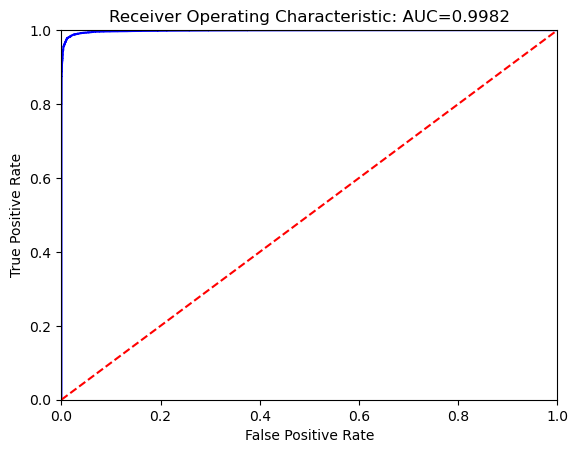

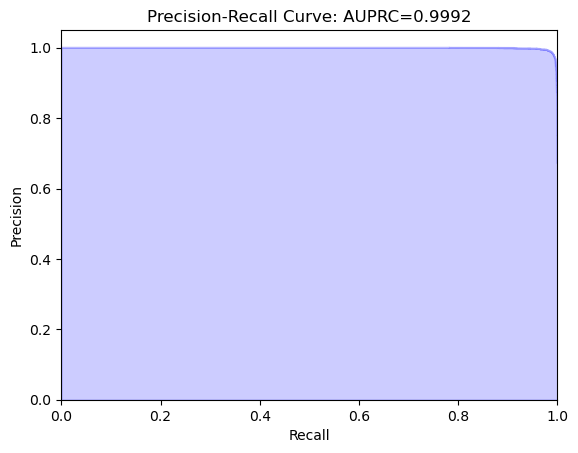

In [19]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('hospitalization_disposition_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)